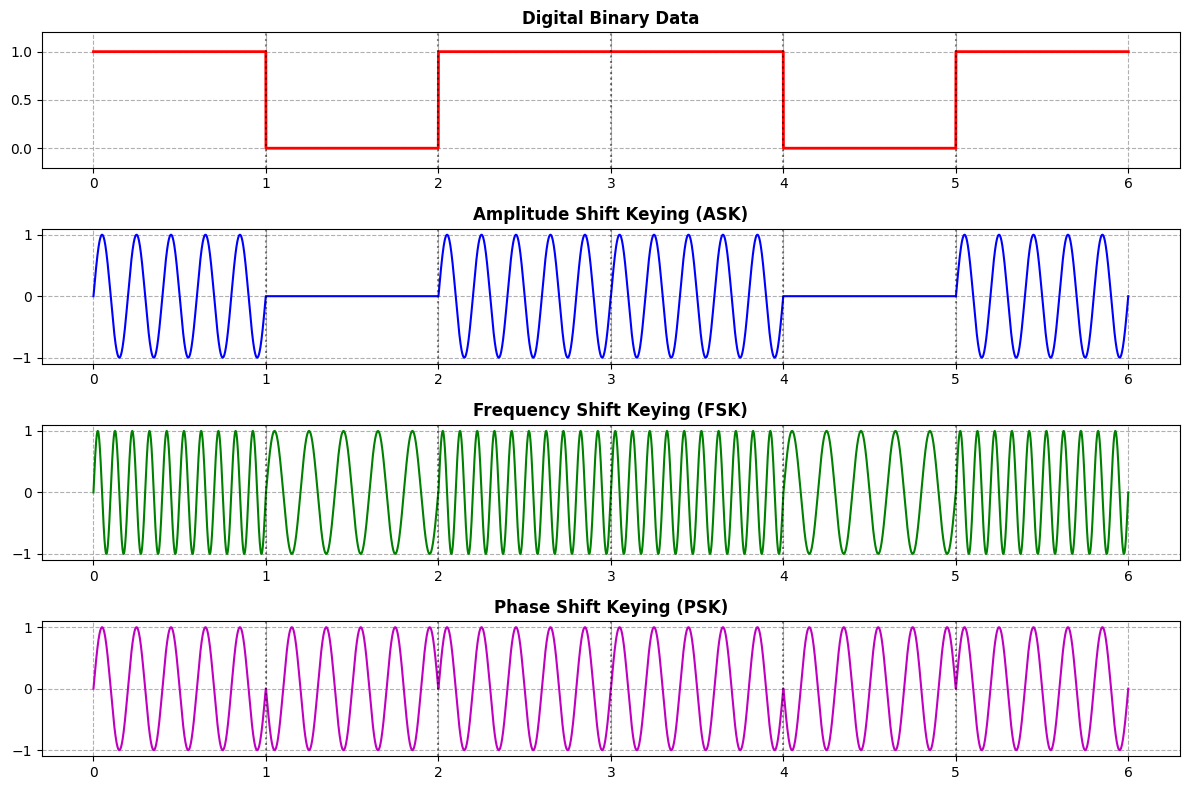

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup Parameters
bits = np.array([1, 0, 1, 1, 0, 1])  # Digital input data
Tb = 1.0  # Time per bit (bit duration)
fs = 1000  # Sampling frequency
samples_per_bit = int(fs * Tb)
t = np.linspace(0, len(bits) * Tb, len(bits) * samples_per_bit)

# Carrier frequencies
fc = 5.0  # Base carrier frequency
fc_high = 10.0  # High frequency for FSK '1'

# 2. Generate Signals
digital_signal = []
ask_signal = []
fsk_signal = []
psk_signal = []

for bit in bits:
    # Time vector for a single bit interval
    t_bit = np.linspace(0, Tb, samples_per_bit)

    # Square wave (Digital Data)
    digital_signal.extend(np.ones(samples_per_bit) * bit)

    # ASK: Amplitude changes (1 = full amplitude, 0 = zero/low amplitude)
    ask_amplitude = 1.0 if bit == 1 else 0.0
    ask_signal.extend(ask_amplitude * np.sin(2 * np.pi * fc * t_bit))

    # FSK: Frequency changes (1 = higher frequency, 0 = lower frequency)
    fsk_freq = fc_high if bit == 1 else fc
    fsk_signal.extend(np.sin(2 * np.pi * fsk_freq * t_bit))

    # PSK: Phase changes (1 = 0 phase shift, 0 = 180 degree phase shift)
    psk_phase = 0 if bit == 1 else np.pi
    psk_signal.extend(np.sin(2 * np.pi * fc * t_bit + psk_phase))

# Convert lists to numpy arrays
digital_signal = np.array(digital_signal)
ask_signal = np.array(ask_signal)
fsk_signal = np.array(fsk_signal)
psk_signal = np.array(psk_signal)

# 3. Plotting
plt.figure(figsize=(12, 8))

# Subplot 1: Digital Data
plt.subplot(4, 1, 1)
plt.plot(t, digital_signal, "r", linewidth=2)
plt.title("Digital Binary Data", fontsize=12, fontweight="bold")
plt.ylim(-0.2, 1.2)
plt.grid(True, linestyle="--")

# Subplot 2: ASK
plt.subplot(4, 1, 2)
plt.plot(t, ask_signal, "b")
plt.title("Amplitude Shift Keying (ASK)", fontsize=12, fontweight="bold")
plt.grid(True, linestyle="--")

# Subplot 3: FSK
plt.subplot(4, 1, 3)
plt.plot(t, fsk_signal, "g")
plt.title("Frequency Shift Keying (FSK)", fontsize=12, fontweight="bold")
plt.grid(True, linestyle="--")

# Subplot 4: PSK
plt.subplot(4, 1, 4)
plt.plot(t, psk_signal, "m")
plt.title("Phase Shift Keying (PSK)", fontsize=12, fontweight="bold")
plt.grid(True, linestyle="--")

# Add bit markings (vertical lines) across all plots for readability
for i in range(1, len(bits)):
    for plot_idx in range(1, 5):
        plt.subplot(4, 1, plot_idx)
        plt.axvline(x=i * Tb, color="black", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.savefig(
    "../../output/ask_fsk_psk.svg",
    format="svg",
    bbox_inches="tight",
)
plt.show()